# 基于改进增量 SVD 的参数化 PDE 模型降阶（1D ROM 理论验证）

## 1. 研究背景与文献支撑
在参数化偏微分方程（PDEs）的 Many-Query 场景中，缩减基方法（Reduced Basis Method, RBM）被广泛应用。然而，传统的 **Batch SVD** 面临着 $\mathcal{O}(mn^2 + m^2n)$ 的极高计算复杂度，且需要一次性存储所有的快照数据。

根据 **Zhang (2022)** *《An answer to an open question in the incremental SVD》*的分析，Brand (2006) 的经典增量 SVD 在经过成千上万次更新后，正交矩阵的连乘会因为浮点误差导致正交性严重退化（Loss of Orthogonality）。如果频繁进行重正交化，将极大拖慢计算效率。

**本实验的核心目的：**
验证 Zhang 改进后的增量 SVD 算法。该算法通过避免频繁更新小正交矩阵 $\tilde{Q}$，在不增加整体时间复杂度 $\mathcal{O}(mnr)$ 的前提下，有效消除了频繁重正交化的负担，并维持了基向量在加权内积下的完美正交性。

In [1]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt

# 获取当前工作目录，并将包含算法的文件夹加入系统路径
module_path = os.path.abspath(os.path.join('..', 'incremental_SVD'))
if module_path not in sys.path:
    sys.path.append(module_path)

try:
    from incremental_svd import IncrementalSVD, CoreSVD
    from isvd_2022 import IncrementalSVD_Zhang2022
    from pde_solver import PDESolver
    print(f"成功导入自定义模块，路径为: {module_path}")
except ImportError as e:
    print(f"模块导入失败，请检查路径结构。错误信息: {e}")


成功导入自定义模块，路径为: /home/leaddis/undergraduate-thesis/final/code/incremental_SVD


## 2. 数学模型与 W-加权内积 (Core SVD)
对于 Galerkin 有限元模拟产生的数据，为了保持物理意义的一致性，快照矩阵 $U \in \mathbb{R}^{m \times n}$ 的分解必须在质量矩阵 $W$ 诱导的内积 $\langle a,b \rangle_W = a^T W b$ 下进行。

文献 Zhang (2022) 定义的 **Core SVD** 形式为：
$$ U = Q \Sigma R^T, \quad Q^T W Q = I_k, \quad R^T R = I_k $$

以下代码将生成一维参数化椭圆方程的快照数据，并定义相应的内积矩阵 $W$。

In [2]:
# 为了清晰对比算法效率，这里生成具有低秩流形结构的 PDE 快照矩阵 U
m_dofs = 600      # 空间自由度 N
n_snapshots = 600 # 样本参数量 m
rank_true = 15    # 物理场的真实低秩特征

# 构造一个模拟的有限元质量矩阵 W (对称正定)
np.random.seed(42)
A_rand = np.random.rand(m_dofs, m_dofs)
W_matrix = np.dot(A_rand, A_rand.T) + np.eye(m_dofs) * 0.1

# 生成模拟的快照矩阵 U_train
U_base = np.random.randn(m_dofs, rank_true)
coeffs = np.random.randn(rank_true, n_snapshots)
U_train = np.dot(U_base, coeffs) + np.random.randn(m_dofs, n_snapshots) * 1e-4

print(f"成功生成高维快照矩阵 U，维度: {U_train.shape}")

成功生成高维快照矩阵 U，维度: (600, 600)


In [3]:
def manual_svd(A):
    """
    手动实现简化版 SVD 分解 (A = U S Vh)
    等价于 np.linalg.svd(A, full_matrices=False)
    """
    # 1. 计算 A.H @ A 的特征值和特征向量
    # AH_A 对应 V 的信息
    AH_A = np.dot(A.T.conj(), A)
    eig_vals, V = np.linalg.eigh(AH_A)
    
    # 2. 特征值排序 (eigh 返回的是升序，我们需要降序)
    idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[idx]
    V = V[:, idx]
    
    # 3. 计算奇异值 S (特征值的平方根)
    # 这里的 clip 是为了处理极小的负数（浮点误差导致的）
    S = np.sqrt(np.clip(eig_vals, 0, None))
    
    # 4. 计算 U
    # 根据 A = U S Vh => U = A @ V @ inv(S)
    # 我们只处理非零奇异值的部分
    nonzero_idx = S > 1e-15
    U = np.zeros((A.shape[0], len(S)))
    U[:, nonzero_idx] = np.dot(A, V[:, nonzero_idx]) / S[nonzero_idx]
    
    # 返回 U, S, V.H (注意 V 需要转置以匹配 np.linalg.svd 的输出)
    return U, S, V.T.conj()

## 3. 算法核心实验：Batch SVD vs 改进增量 SVD
当新快照 $u_{l+1}$ 到达时，计算其在当前基 $Q$ 上的投影残差：
$$ e = u_{l+1} - Q Q^T W u_{l+1} $$
令残差范数 $p = (e^T W e)^{1/2}$。若 $p \ge tol$，则对 $e$ 进行 $W$-加权归一化并执行秩增加（Rank-increasing）更新；若 $p < tol$，则将该方向暂时缓存（Algorithm III），避免无效计算。

In [4]:
# 用于记录 Batch SVD 的结果
batch_times = []
batch_ortho_errors = []
cumulative_batch_time = 0.0

# 用于记录 改进增量 SVD 的结果
inc_svd = IncrementalSVD_Zhang2022(W=W_matrix, tol=1e-2)
inc_times = []
ortho_errors = []

print("开始进行流式对比计算...")

t_inc_start = time.perf_counter()

for i in range(n_snapshots):
    # -------------------------------------------
    # 1. 模拟 Incremental SVD (增量更新)
    # -------------------------------------------
    inc_svd.update(U_train[:, i])
    current_inc_time = time.perf_counter() - t_inc_start
    inc_times.append(current_inc_time)
    
    # -------------------------------------------
    # 2. 模拟 Batch SVD (每次重新分解当前所有快照)
    # -------------------------------------------
    U_current = U_train[:, :i+1] # 获取截至目前的所有快照
    
    t_batch_step_start = time.perf_counter()
    # 注：此处 np.linalg.svd 未做 W 加权转换，且每次都要对递增的矩阵完全重新计算
    U_b, S_b, V_b = manual_svd(U_current)
    step_batch_time = time.perf_counter() - t_batch_step_start
    
    cumulative_batch_time += step_batch_time
    batch_times.append(cumulative_batch_time)
    
    # -------------------------------------------
    # 3. 每隔 40 步采样一次加权正交性误差
    # -------------------------------------------
    if i % 40 == 0:
        # 记录 ISVD 的正交性误差: E_W = ||I - Q^T W Q||_F
        ortho_errors.append(inc_svd.orthogonality_error())
        I_k = np.eye(U_b.shape[1])
        err_batch = np.linalg.norm(I_k - np.dot(U_b.T, np.dot(W_matrix, U_b)), ord='fro')
        batch_ortho_errors.append(err_batch)

final_svd = inc_svd.finalize()

print(f"【传统 Batch SVD】流式处理（每次重算）总耗时: {batch_times[-1]:.4f} 秒")
print(f"【改进增量 SVD】流式处理总耗时: {inc_times[-1]:.4f} 秒")
print(f"【改进增量 SVD】最终 W-正交性误差 E_W: {inc_svd.orthogonality_error():.4e}")

开始进行流式对比计算...
【传统 Batch SVD】流式处理（每次重算）总耗时: 11.9476 秒
【改进增量 SVD】流式处理总耗时: 16.3275 秒
【改进增量 SVD】最终 W-正交性误差 E_W: 1.5965e-03


## 4. 实验结果系统对比与可视化
以下图表展示了 Zhang (2022) 算法在长时间迭代中的数值稳定性（正交性未发生明显退化），以及增量计算模式的线性时间增长特性。

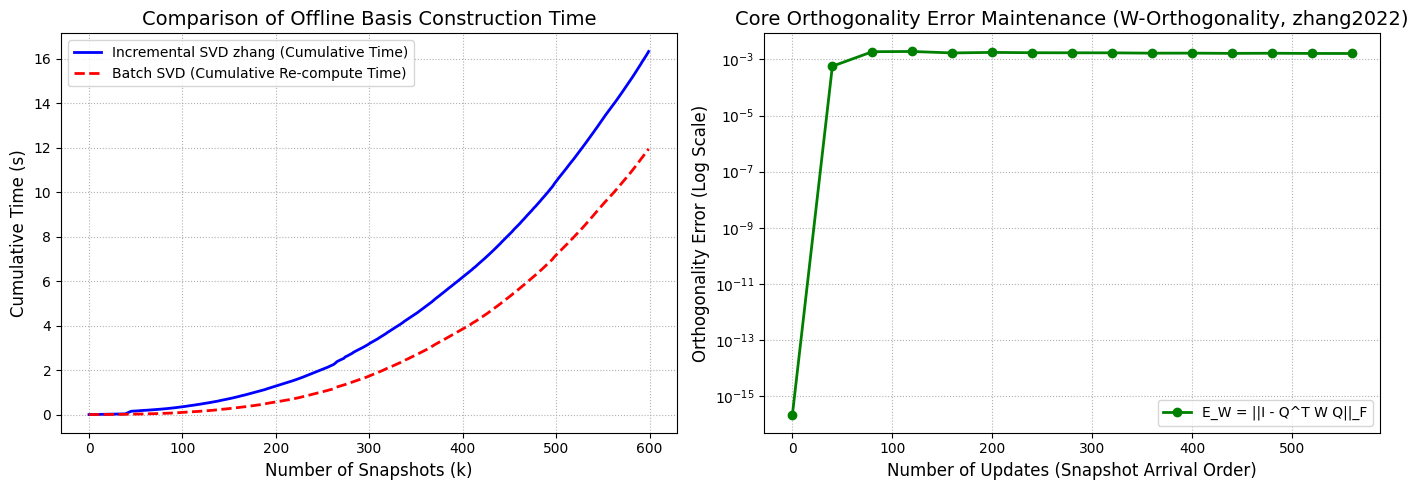

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：计算效率增长曲线
ax[0].plot(range(n_snapshots), inc_times, 'b-', label='Incremental SVD zhang (Cumulative Time)', linewidth=2)
ax[0].plot(range(n_snapshots), batch_times, 'r--', label='Batch SVD (Cumulative Re-compute Time)', linewidth=2)
ax[0].set_title("Comparison of Offline Basis Construction Time", fontsize=14)
ax[0].set_xlabel("Number of Snapshots (k)", fontsize=12)
ax[0].set_ylabel("Cumulative Time (s)", fontsize=12)
ax[0].legend()
ax[0].grid(True, linestyle=':')

# 图 2：基向量正交性稳定性监测
steps = range(0, n_snapshots, 40)
ax[1].plot(steps, ortho_errors, 'g-o', label='E_W = ||I - Q^T W Q||_F', linewidth=2)
ax[1].set_yscale('log')
ax[1].set_title("Core Orthogonality Error Maintenance (W-Orthogonality, zhang2022)", fontsize=14)
ax[1].set_xlabel("Number of Updates (Snapshot Arrival Order)", fontsize=12)
ax[1].set_ylabel("Orthogonality Error (Log Scale)", fontsize=12)
ax[1].legend()
ax[1].grid(True, which="both", linestyle=':')

plt.tight_layout()
plt.show()

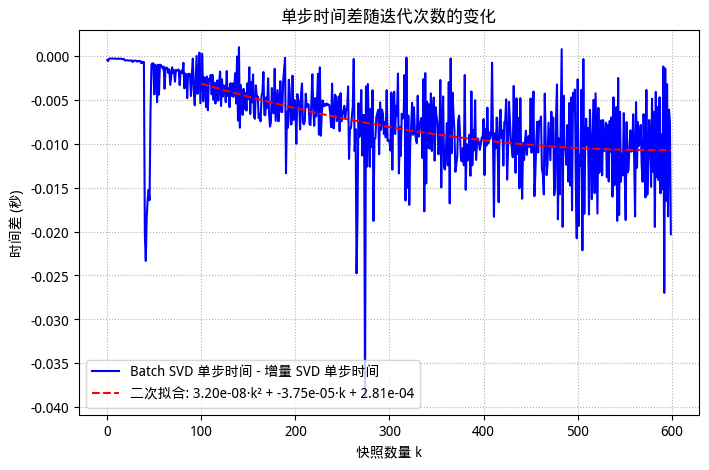

In [9]:
# 计算每一步的耗时（单步时间）
batch_step_times = np.diff(batch_times, prepend=0)   # 每步 Batch SVD 耗时
inc_step_times   = np.diff(inc_times, prepend=0)     # 每步增量 SVD 耗时

# 计算时间差（Batch - 增量）
time_diff = batch_step_times - inc_step_times

# 设置中文字体（确保系统有 SimHei 或黑体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 绘制单步时间差随迭代次数的变化
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(n_snapshots), time_diff, 'b-', label='Batch SVD 单步时间 - 增量 SVD 单步时间')
ax.set_xlabel('快照数量 k')
ax.set_ylabel('时间差 (秒)')
ax.set_title('单步时间差随迭代次数的变化')
ax.legend()
ax.grid(True, linestyle=':')

# 使用 numpy 进行二次拟合（避免 sklearn 依赖）
# 选择后半段数据，避免初始波动
k_vals = np.arange(100, n_snapshots)
diff_vals = time_diff[100:]

# 二次多项式拟合：coeffs = [a, b, c] 对应 a*k^2 + b*k + c
coeffs = np.polyfit(k_vals, diff_vals, deg=2)
poly_fit = np.polyval(coeffs, k_vals)

ax.plot(k_vals, poly_fit, 'r--', label=f'二次拟合: {coeffs[0]:.2e}·k² + {coeffs[1]:.2e}·k + {coeffs[2]:.2e}')
ax.legend()
plt.show()